In [15]:
# imports
import os
import time
import pickle
import pandas as pd
import argparse
import numpy as np
import xgboost as xgb
import sklearn
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE, RFECV
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split

from utils_pyradiomics import preprocessing_train, preprocessing_test, get_optimal_threshold
#from preprocessing.radiomics_extraction import initialize_feature_extractor,generate_features_table
#from radiomics_pipeline.utils import preprocessing_train, preprocessing_test

In [2]:
# merge outcome with pyradiomics feature table

clinical_df = pd.read_csv(os.path.expanduser('~/project/xAI-in-NSCLC/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv'))
features_df = pd.read_csv(os.path.expanduser('~/project/xAI-in-NSCLC/FULL_radiomics_features_per_slice.csv'))
print(clinical_df.shape, features_df.shape)

(422, 10) (7223, 662)


In [3]:
merged_df = pd.merge(features_df, clinical_df[['PatientID', 'Histology']], on='PatientID', how='left')
merged_df = merged_df.sort_values(by=['PatientID'], ascending=True)

In [4]:
merged_df_clean = merged_df.dropna(subset=['Histology'])

In [5]:
merged_df_clean['Histology'].unique()

array(['large cell', 'squamous cell carcinoma', 'adenocarcinoma', 'nos'],
      dtype=object)

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

/home/coder/project/xAI-in-NSCLC/.venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/coder/project/xAI-in-NSCLC/.venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


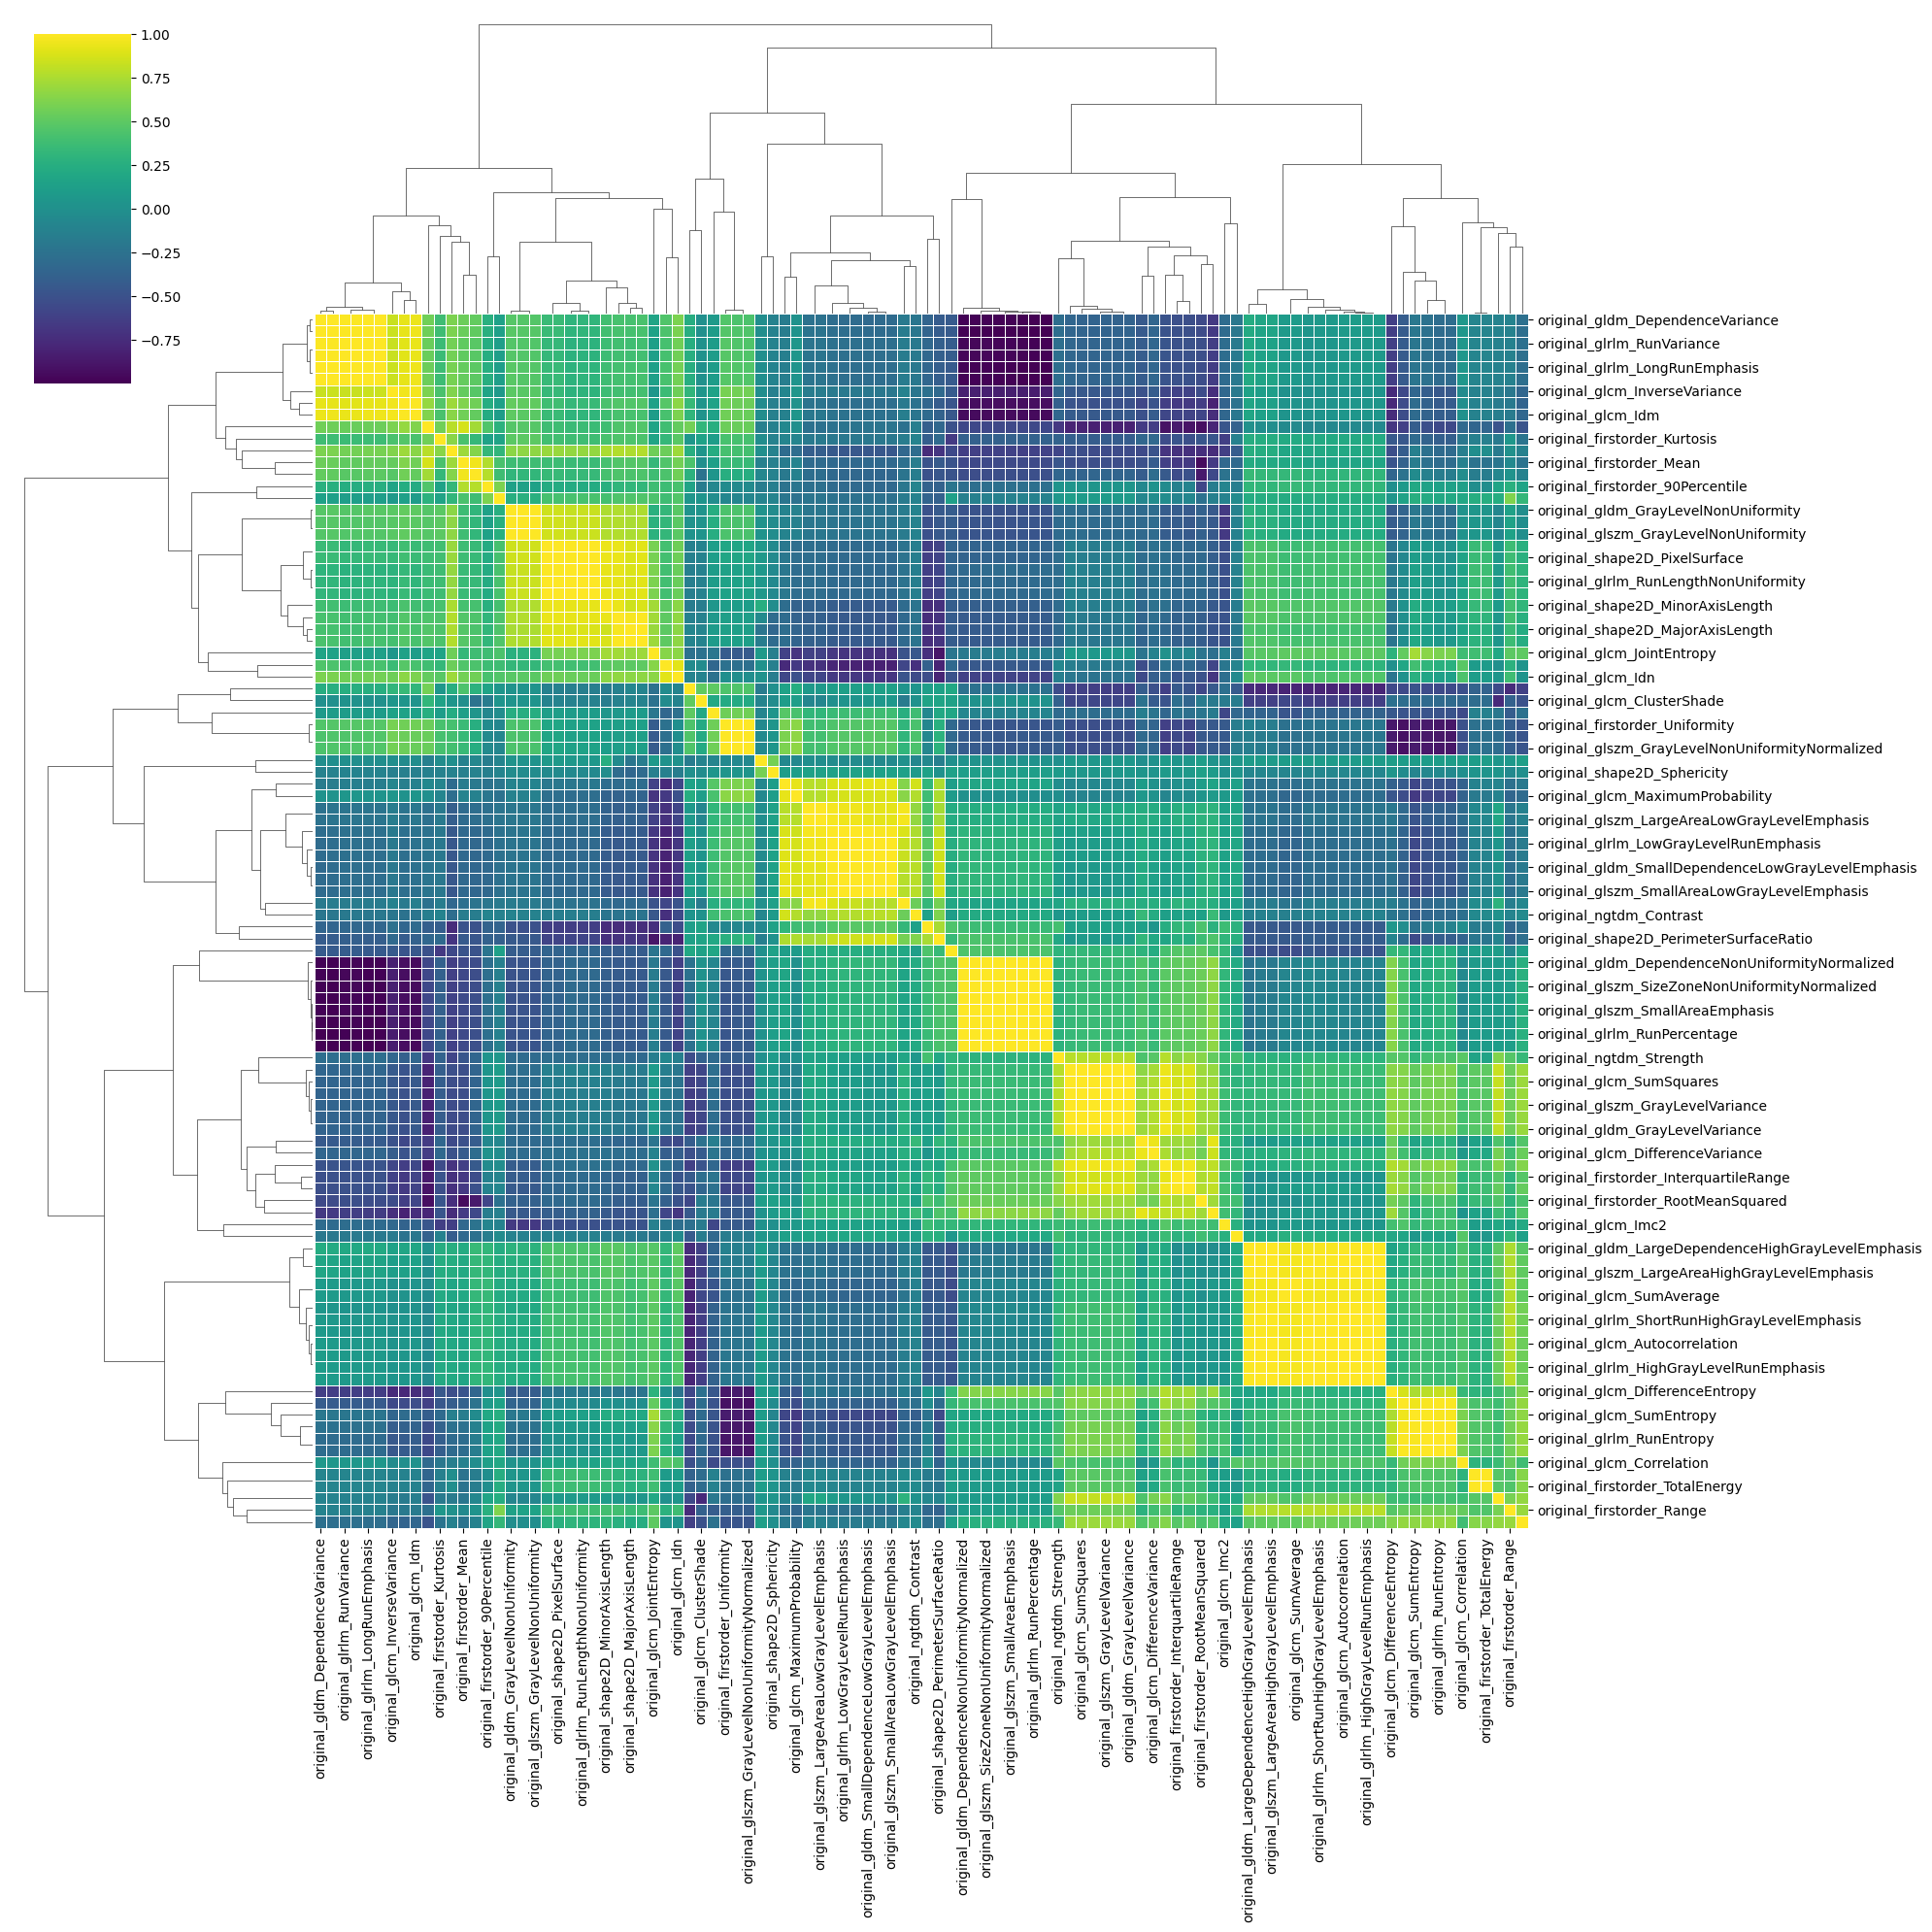

In [28]:
df = merged_df_clean.drop(labels=['slice_no', 'Histology'], axis=1) # 'PatientID'

d_per_pat = df.groupby("PatientID").sample(n=1, random_state=42).reset_index(drop=True)
d_per_pat.drop(labels='PatientID', axis=1)

feature_names = sorted(filter ( lambda k: k.startswith("original_"), d_per_pat.columns))
#make dataframe with features
d = d_per_pat.loc[:,feature_names]


# Choose a subset of features for clustering
dd = d.iloc[:,:]

pp = sns.clustermap(dd.corr(),cmap='viridis', linewidths=.5, figsize=(20,20))
_ = plt.setp(pp.ax_heatmap.get_yticklabels(), rotation=0)

#plt.show()

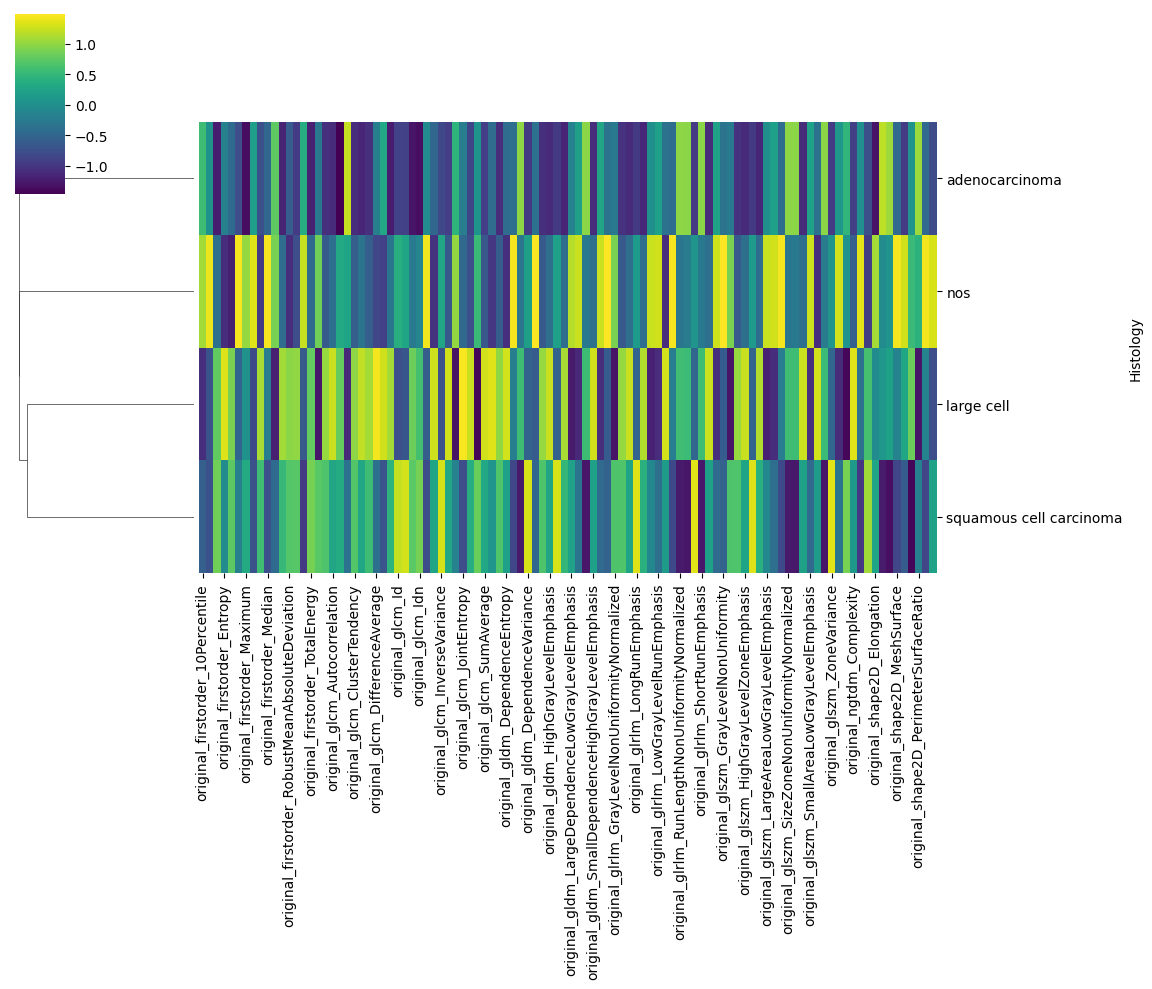

In [38]:
#Note that this view removes variables that have a z-score below 1, and are thereofre not statistically significant. 

df = merged_df_clean.drop(labels=['PatientID', 'slice_no'], axis=1) # 'PatientID'

d_per_his = df.groupby("Histology").mean()

feature_names = sorted(filter ( lambda k: k.startswith("original_"), d_per_his.columns))
#make dataframe with features
d = d_per_his.loc[:,feature_names]
dd = d.iloc[:,:]

pp = sns.clustermap(dd, cmap='viridis', col_cluster=False, metric='chebyshev', z_score=1)
_ = plt.setp(pp.ax_heatmap.get_yticklabels(), rotation=0)
plt.show()

In [6]:
mapping = {'adenocarcinoma': 0, 'squamous cell carcinoma': 1, 'large cell': 2, 'nos':3 }
merged_df_clean['Histology'] = merged_df_clean['Histology'].map(mapping)
merged_df_clean['Histology'].unique()

/tmp/ipykernel_4025981/2304721031.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_clean['Histology'] = merged_df_clean['Histology'].map(mapping)


array([2, 1, 0, 3])

In [7]:
# run this cell if you want per pattient training
merged_df_clean = merged_df_clean.groupby(by='PatientID').sample(n=1, random_state=42).reset_index(drop=True)

In [7]:
#test train split NOT by patient ID, but by slice

X = merged_df_clean.drop(columns=['PatientID', 'Histology'])
y = merged_df_clean['Histology']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [7]:
# test train split by patient ID
temp_df = clinical_df.dropna(subset=['Histology'])
X = temp_df['PatientID']
y = temp_df['Histology']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=204, stratify=y)

#save patient IDs for deep learning test train split later
train_labels = X_train.unique()
test_labels = X_test.unique()

In [8]:
#create test train split dfs for training
X_train = merged_df_clean.loc[merged_df_clean['PatientID'].isin(train_labels)]
y_train = X_train['Histology']
X_test = merged_df_clean.loc[merged_df_clean['PatientID'].isin(test_labels)]
y_test = X_test['Histology']

X_train = X_train.drop(columns=['PatientID', 'Histology', 'slice_no'])
X_test = X_test.drop(columns=['PatientID', 'Histology', 'slice_no'])

In [9]:
# preprocess training dataset first 
mean_std, selector, to_drop, decor_dataset_train = preprocessing_train(X_train)
decor_dataset_test = preprocessing_test(X_test, mean_std, selector, to_drop)
print('features processed. New shape of training dataset:', decor_dataset_train.shape, 'before:', X_train.shape)

features processed. New shape of training dataset: (4735, 54) before: (4735, 660)


In [10]:
print(f'y_train: {y_train.value_counts()/len(y_train)} N = {len(y_train)}')
print(f'y_test: {y_test.value_counts()/len(y_test)} N = {len(y_test)}')

y_train: Histology
1    0.404857
2    0.297149
3    0.168321
0    0.129673
Name: count, dtype: float64 N = 4735
y_test: Histology
1    0.407164
2    0.312311
0    0.142785
3    0.137740
Name: count, dtype: float64 N = 1982


In [11]:
# model definition
model = xgb.XGBClassifier(enable_categorical=True, colsample_bytree=1, eta=0.01, max_depth=4,
                            objective='multi:softprob', eval_metric='logloss', nthread=8,
                            gamma=0.5, seed=204)

#note: can add 'device=cuda' to use GPU

#could you increase the number of threads for efficiency? To what number shoudl I increase it to?

#I think 32 is the limit for this environment.
# Hence using 8 threads + 4 jobs 

In [ ]:
# test to assume training time

#start = time.time()
#model.fit(X_train, y_train)
#T_single = time.time() - start
#print(T_single)


/home/coder/project/xAI-in-NSCLC/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [13:54:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


11.648787260055542


In [11]:
#recursive feature elimination with no cross validation:

rfe = RFE(estimator=model, n_features_to_select=10)
rfe.fit(decor_dataset_train, y_train)
support = rfe.support_


In [12]:
# recursive feature elimination with cross validation:
min_features_to_select = 1  # Minimum number of features to consider
rfecv = RFECV(estimator=model, step=1, cv=StratifiedKFold(10),
            scoring='roc_auc_ovr_weighted',
            min_features_to_select=min_features_to_select)
rfecv.fit(decor_dataset_train, y_train)
support = rfecv.support_

In [16]:
rfecv.cv_results_

{'mean_test_score': array([0.47468733, 0.51816635, 0.52481655, 0.53805158, 0.5401489 ,
        0.54869677, 0.55051178, 0.54321544, 0.54246379, 0.54002378,
        0.54115172, 0.5392394 , 0.53651323, 0.53421187, 0.53502868,
        0.53722342, 0.53791844, 0.53901816, 0.5391097 , 0.54416611,
        0.54445504, 0.54027468, 0.54076844, 0.53849439, 0.54223967,
        0.5437053 , 0.54530361, 0.54954866, 0.55158815, 0.55121588,
        0.55097901, 0.55127133, 0.55087712, 0.55255986, 0.55082751,
        0.55093118, 0.54999784, 0.55010173, 0.5512366 , 0.55057365,
        0.54935605, 0.54934303, 0.54908419, 0.54921189, 0.54912106,
        0.54895838, 0.55065557, 0.55389141, 0.55415757, 0.55410984,
        0.55376295, 0.55338735, 0.55338878, 0.55356579]),
 'std_test_score': array([0.06084175, 0.06962989, 0.07173524, 0.07019838, 0.07085368,
        0.07277279, 0.06923686, 0.0729915 , 0.07415291, 0.0761945 ,
        0.07419483, 0.07240106, 0.06580692, 0.06941352, 0.07123951,
        0.07064271, 0

In [23]:
path_to_save = os.path.expanduser('~/project/xAI-in-NSCLC')

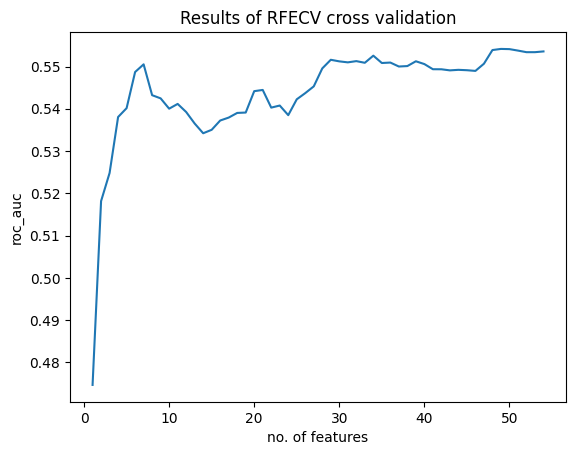

In [27]:
fig, ax = plt.subplots()
mean_scores = rfecv.cv_results_['mean_test_score']
no_features = rfecv.cv_results_['n_features']
ax.plot(no_features, mean_scores)
ax.set(xlabel='no. of features', ylabel='roc_auc')
ax.set_title('Results of RFECV cross validation')
fig.savefig(path_to_save + r'/RFECV_results.png')

In [12]:
filtered_col = np.extract(support, np.array(decor_dataset_train.columns))
reduced_features_train_set = decor_dataset_train[filtered_col]

In [13]:
filtered_col

array(['original_firstorder_10Percentile', 'original_firstorder_Maximum',
       'original_firstorder_Median', 'original_firstorder_Range',
       'original_glcm_ClusterShade',
       'log-sigma-0-1-mm-3D_firstorder_90Percentile',
       'log-sigma-0-1-mm-3D_firstorder_Energy',
       'log-sigma-0-1-mm-3D_glcm_Correlation',
       'wavelet-H_firstorder_Maximum', 'wavelet-H_glcm_Correlation'],
      dtype=object)

In [ ]:
#original cross validation search
param_test_xgb = {
        'max_depth': range(2, 4, 1),
        'min_child_weight': range(1, 6, 2),
        'gamma': [i * 0.1 for i in range(1, 10)], #was originally [i * 0.1 for i in range(1, 10)]
        'n_estimators': [int(x) for x in np.linspace(start=10, stop=1000, num=100)],
        'learning_rate': [10 ** (-i) for i in range(2, 3)] # was originally [10 ** (-i) for i in range(2, 7)]
    }

In [14]:
param_test_xgb = {
        'max_depth': range(3, 6, 1),
        'min_child_weight': [1],
        'gamma': [0, 0.2, 0.4], #was originally [i * 0.1 for i in range(1, 10)]
        'n_estimators': [200, 300, 400], #int(x) for x in np.linspace(start=200, stop=400, num=100)
    }

In [15]:
kfold = StratifiedKFold(n_splits=5, random_state=204, shuffle=True) #increase this back to 10 ?
gsearch = GridSearchCV(model, param_grid=param_test_xgb, scoring='roc_auc_ovr_weighted', n_jobs=4, cv=kfold, verbose=2)

In [16]:
gsearch.fit(reduced_features_train_set, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=200; total time=   0.8s
[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=200; total time=   1.1s
[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=200; total time=   1.1s
[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=200; total time=   1.2s
[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=200; total time=   1.0s
[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=300; total time=   1.3s
[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=300; total time=   1.7s
[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=300; total time=   1.7s
[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=300; total time=   1.7s
[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=300; total time=   1.6s
[CV] END gamma=0, max_depth=3, min_child_weight=1, n_estimators=400; total time=   1.9s
[CV] END gamma=0, max_depth=3, m

,estimator,"XGBClassifier...obs=None, ...)"
,param_grid,"{'gamma': [0, 0.2, ...], 'max_depth': range(3, 6), 'min_child_weight': [1], 'n_estimators': [200, 300, ...]}"
,scoring,'roc_auc_ovr_weighted'
,n_jobs,4
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [17]:
reduced_features_test_set = decor_dataset_test[filtered_col]

best_estimator = gsearch.best_estimator_

proba_train = best_estimator.predict_proba(reduced_features_train_set)
proba_test = best_estimator.predict_proba(reduced_features_test_set)


In [18]:
proba_train = rfe.estimator_.predict_proba(reduced_features_train_set)
proba_test = rfe.estimator_.predict_proba(reduced_features_test_set)

In [ ]:
def get_multiclass_results(y_true, proba, label, average='weighted'):
    ## multiclass classification: choose argmax class and evaluate multiclass metrics
    y_true = np.asarray(y_true)
    y_pred = np.argmax(proba, axis=1)
    classes = np.unique(y_true)
    y_true_bin = sklearn.preprocessing.label_binarize(y_true, classes=classes)
    dict_results = {}
    dict_results["auc_ovr_weighted"] = sklearn.metrics.roc_auc_score(
        y_true_bin,
        np.asarray(proba),
        multi_class='ovr',
        average=average # maybe it's something to do with this?
    )
    dict_results["accuracy"] = sklearn.metrics.accuracy_score(y_true, y_pred)
    dict_results["precision"] = sklearn.metrics.precision_score(y_true, y_pred, average=average, zero_division=0)
    dict_results["recall"] = sklearn.metrics.recall_score(y_true, y_pred, average=average, zero_division=0)
    dict_results["f1 score"] = sklearn.metrics.f1_score(y_true, y_pred, average=average, zero_division=0)
    df_results = pd.DataFrame.from_dict([dict_results])
    df_results.index = [label]
    return df_results

In [24]:
results_train = get_multiclass_results(y_train, proba_train, "train")
results_test = get_multiclass_results(y_test, proba_test, "test")

In [25]:
results_train

,auc_ovr_weighted,accuracy,precision,recall,f1 score
train,0.721022,0.467773,0.626996,0.467773,0.373607


In [26]:
results_test

,auc_ovr_weighted,accuracy,precision,recall,f1 score
test,0.671922,0.449405,0.48474,0.449405,0.350824


In [ ]:
# some bug in the code. Surely.